# Meta-Risk Campaign Notebook

Executable notebook for the 4-variant meta-risk overlay campaign.


In [1]:
from pathlib import Path
import sys

root = Path.cwd().resolve()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent

if not (root / "pyproject.toml").exists():
    raise RuntimeError("Could not locate repository root from current working directory.")

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f"Project root: {root}")


Project root: D:\Business\Trading\VSCODE\algo-trading-intraday-research


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.analytics.meta_risk_campaign import (
    BaseStrategySpec,
    ChallengeSimulationConfig,
    MetaRiskCampaignSpec,
    run_meta_risk_campaign,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 120)


In [3]:
OUTPUT_DIR = root / "data" / "exports" / "meta_risk_campaign_20260320_231000"

spec = MetaRiskCampaignSpec(
    strategy=BaseStrategySpec(
        dataset_path=root / "data" / "raw" / "MNQ_1mim.parquet",
        is_fraction=0.7,
        initial_capital_usd=50000.0,
        risk_per_trade_pct=0.25,
        or_minutes=15,
        opening_time="09:30:00",
        time_exit="16:00:00",
        side_mode="long_only",
        entry_buffer_ticks=0,
        stop_buffer_ticks=2,
        target_multiple=5.0,
        entry_on_next_open=True,
        atr_period=14,
        atr_q_low=0.5,
        atr_q_high=1.0,
        ema_length=30,
        direction_filter_mode="ema_only",
        execution_profile="repo_realistic",
    ),
    challenge=ChallengeSimulationConfig(
        target_return_pct=0.06,
        max_drawdown_pct=0.04,
        n_bootstrap_paths=5000,
        horizon_days=None,
        random_seed=42,
    ),
)


In [4]:
artifacts = run_meta_risk_campaign(spec=spec, output_dir=OUTPUT_DIR, notebook_path=None)
for name, path in artifacts.items():
    print(f"{name}: {path}")


output_dir: D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\meta_risk_campaign_20260320_231000
comparative_csv: D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\meta_risk_campaign_20260320_231000\tables\meta_risk_comparative_metrics.csv
ranking_csv: D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\meta_risk_campaign_20260320_231000\tables\meta_risk_ranking.csv
challenge_csv: D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\meta_risk_campaign_20260320_231000\tables\meta_risk_challenge_simulation.csv
curves_png: D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\meta_risk_campaign_20260320_231000\curves\equity_drawdown_curves.png
report_md: D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\meta_risk_campaign_20260320_231000\summary\meta_risk_report.md
curves_dir: D:\Business\Trading\VSCODE\algo-trading-intraday-research\data\exports\meta_risk_campaign_20260320

In [5]:
ranking = pd.read_csv(artifacts["ranking_csv"])
compare = pd.read_csv(artifacts["comparative_csv"])
display(ranking)
display(compare)


,variant,variant_label,overall_pnl,overall_trades,overall_win_rate,overall_profit_factor,overall_expectancy,overall_sharpe,overall_max_drawdown,is_pnl,is_trades,is_win_rate,is_profit_factor,is_expectancy,is_sharpe,is_max_drawdown,oos_pnl,oos_trades,oos_win_rate,oos_profit_factor,oos_expectancy,oos_sharpe,oos_max_drawdown,challenge_target_return_pct,challenge_drawdown_limit_pct,challenge_drawdown_limit_usd,challenge_target_usd,challenge_horizon_days,challenge_bootstrap_paths,challenge_pass_rate,challenge_success_count,challenge_median_days_to_target,challenge_mean_days_to_target,challenge_p25_days_to_target,challenge_p75_days_to_target,historical_path_pass,historical_days_to_target,oos_abs_max_drawdown,challenge_days_for_sort,selection_rank
0,baseline,1_baseline,4457.5,261,0.448276,1.326246,17.078544,0.722458,-934.5,2743.5,205,0.448780,1.256270,13.382927,0.623333,-934.5,1714.0,56,0.446429,1.579544,30.607143,0.970865,-779.0,0.06,0.04,2000.0,3000.0,529,5000,0.173,865,423.0,406.957225,355.0,478.0,False,NaN,779.0,423.0,1
1,skip_day_after_3_losses,3_skip_after_3_losses,4580.5,260,0.450000,1.338294,17.617308,0.743469,-934.5,2866.5,204,0.450980,1.270872,14.051471,0.652572,-934.5,1714.0,56,0.446429,1.579544,30.607143,0.970865,-779.0,0.06,0.04,2000.0,3000.0,529,5000,0.173,865,423.0,406.957225,355.0,478.0,False,NaN,779.0,423.0,2
2,half_after_2_losses,2_half_after_2_losses,533.5,66,0.393939,1.154213,8.083333,0.184553,-934.5,595.0,65,0.400000,1.175103,9.153846,0.246484,-934.5,-61.5,1,0.000000,0.000000,-61.500000,-0.690849,-61.5,0.06,0.04,2000.0,3000.0,529,5000,0.000,0,NaN,NaN,NaN,NaN,False,NaN,61.5,inf,3
3,local_drawdown_scaling,4_local_drawdown_scaling,-156.0,44,0.409091,0.928160,-3.545455,-0.082173,-695.0,-94.5,43,0.418605,0.955213,-2.197674,-0.059732,-633.5,-61.5,1,0.000000,0.000000,-61.500000,-0.690849,-61.5,0.06,0.04,2000.0,3000.0,529,5000,0.000,0,NaN,NaN,NaN,NaN,False,NaN,61.5,inf,4


,variant,variant_label,overall_pnl,overall_trades,overall_win_rate,overall_profit_factor,overall_expectancy,overall_sharpe,overall_max_drawdown,is_pnl,is_trades,is_win_rate,is_profit_factor,is_expectancy,is_sharpe,is_max_drawdown,oos_pnl,oos_trades,oos_win_rate,oos_profit_factor,oos_expectancy,oos_sharpe,oos_max_drawdown,challenge_target_return_pct,challenge_drawdown_limit_pct,challenge_drawdown_limit_usd,challenge_target_usd,challenge_horizon_days,challenge_bootstrap_paths,challenge_pass_rate,challenge_success_count,challenge_median_days_to_target,challenge_mean_days_to_target,challenge_p25_days_to_target,challenge_p75_days_to_target,historical_path_pass,historical_days_to_target
0,baseline,1_baseline,4457.5,261,0.448276,1.326246,17.078544,0.722458,-934.5,2743.5,205,0.448780,1.256270,13.382927,0.623333,-934.5,1714.0,56,0.446429,1.579544,30.607143,0.970865,-779.0,0.06,0.04,2000.0,3000.0,529,5000,0.173,865,423.0,406.957225,355.0,478.0,False,NaN
1,half_after_2_losses,2_half_after_2_losses,533.5,66,0.393939,1.154213,8.083333,0.184553,-934.5,595.0,65,0.400000,1.175103,9.153846,0.246484,-934.5,-61.5,1,0.000000,0.000000,-61.500000,-0.690849,-61.5,0.06,0.04,2000.0,3000.0,529,5000,0.000,0,NaN,NaN,NaN,NaN,False,NaN
2,skip_day_after_3_losses,3_skip_after_3_losses,4580.5,260,0.450000,1.338294,17.617308,0.743469,-934.5,2866.5,204,0.450980,1.270872,14.051471,0.652572,-934.5,1714.0,56,0.446429,1.579544,30.607143,0.970865,-779.0,0.06,0.04,2000.0,3000.0,529,5000,0.173,865,423.0,406.957225,355.0,478.0,False,NaN
3,local_drawdown_scaling,4_local_drawdown_scaling,-156.0,44,0.409091,0.928160,-3.545455,-0.082173,-695.0,-94.5,43,0.418605,0.955213,-2.197674,-0.059732,-633.5,-61.5,1,0.000000,0.000000,-61.500000,-0.690849,-61.5,0.06,0.04,2000.0,3000.0,529,5000,0.000,0,NaN,NaN,NaN,NaN,False,NaN


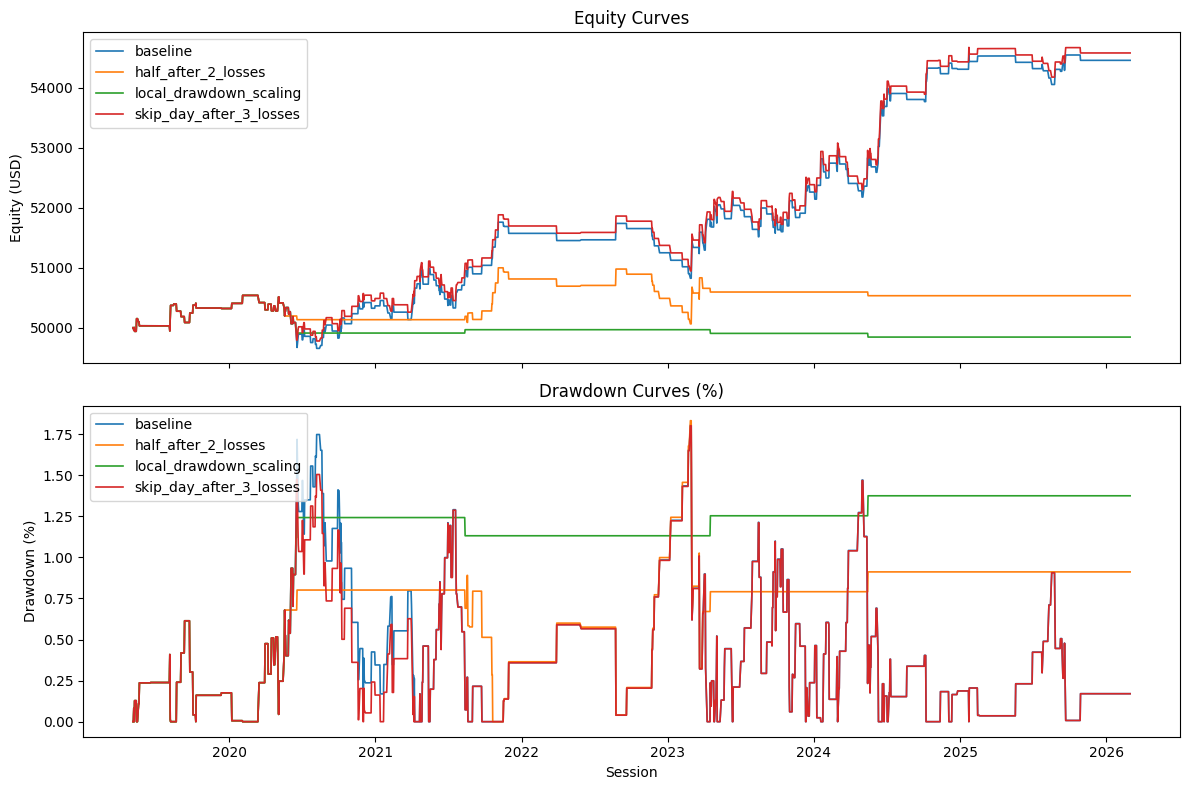

In [6]:
from pathlib import Path

curves_dir = Path(artifacts["curves_dir"])
variant_files = sorted(curves_dir.glob("equity_curve__*.csv"))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for path in variant_files:
    curve = pd.read_csv(path)
    label = path.stem.replace("equity_curve__", "")
    x = pd.to_datetime(curve["session_date"])
    axes[0].plot(x, curve["equity"], label=label, linewidth=1.2)
    axes[1].plot(x, 100.0 * curve["drawdown_pct"], label=label, linewidth=1.2)

axes[0].set_title("Equity Curves")
axes[0].set_ylabel("Equity (USD)")
axes[0].legend(loc="best")
axes[1].set_title("Drawdown Curves (%)")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Session")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


## Notes

- Ranking priority is: challenge pass rate, then time to +6%, then drawdown, then Sharpe/PF/expectancy.
- Overlay controls do not alter entry signal generation.
- Read `meta_risk_report.md` for the written conclusion and caveats.
